# Classification using XGBoost

**Aim:** To classify countries as "High" or "Low" vaccination levels (>= 60% fully vaccinated) using an XGBoost model.

**Model:** `XGBClassifier` (Extreme Gradient Boosting).

**Reasoning:**
XGBoost is a powerful decision-tree-based ensemble model, famous for its
high performance. It iteratively builds new trees that correct the errors
of previous ones. It's excellent at capturing complex, non-linear 
interactions and provides a "feature importance" score, which gives us
a deep insight into *which* features are most predictive.

**Note:** Tree-based models like XGBoost are not sensitive to the 
scale of features, so we do not need to apply `StandardScaler`.

# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier, plot_importance

In [3]:
# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Data Loading & Feature Engineering

In [4]:
df = pd.read_csv("vaccinations.csv")

In [5]:
df['date'] = pd.to_datetime(df['date'])

In [6]:
# --- Apply robust forward-fill logic ---
vax_columns = [
    'people_fully_vaccinated_per_hundred', 'total_boosters_per_hundred',
    'daily_vaccinations_per_million', 'daily_vaccinations'
]
df = df.sort_values(by=['iso_code', 'date'])
df[vax_columns] = df.groupby('iso_code')[vax_columns].ffill()
df[vax_columns] = df[vax_columns].fillna(0)

In [7]:
# --- Step 1: Prepare the Base DataFrame for Modeling ---
# Start with the latest data for each country.
model_df = df.loc[df.groupby('location')['date'].idxmax()].copy()

In [8]:
# --- Step 2: Create 'campaign_duration_days' feature ---
campaign_start_dates = df.groupby('location')['date'].min().reset_index().rename(columns={'date': 'campaign_start'})
model_df = model_df.merge(campaign_start_dates, on='location')
model_df['campaign_duration_days'] = (model_df['date'] - model_df['campaign_start']).dt.days

In [9]:
# --- Step 3: Filter out entries with zero values ---
model_df = model_df[model_df['daily_vaccinations_per_million'] > 0].copy()

In [10]:
# --- Step 4: Create the Target Variable ('vaccination_level') ---
threshold = 60
model_df['vaccination_level'] = np.where(model_df['people_fully_vaccinated_per_hundred'] >= threshold, 1, 0)

print(f"Target variable 'vaccination_level' created (1 if >= {threshold}%, 0 otherwise).")

Target variable 'vaccination_level' created (1 if >= 60%, 0 otherwise).


In [11]:
# --- Step 5: Define Features (X) and Target (y) ---
feature_cols = [
    'total_boosters_per_hundred',
    'daily_vaccinations_per_million',
    'campaign_duration_days'
]

X = model_df[feature_cols]
y = model_df['vaccination_level']

print(f"Features selected: {feature_cols}")

Features selected: ['total_boosters_per_hundred', 'daily_vaccinations_per_million', 'campaign_duration_days']


# Split Data

In [12]:
# Split data into training (80%) and testing (20%) sets
# We do NOT need to scale the data for XGBoost.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Build and Train the XGBoost Model

In [13]:
# Initialize the XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=100,           # Number of trees to build
    learning_rate=0.1,          # How much to shrink the contribution of each tree
    max_depth=3,                # Max depth of each tree (to prevent overfitting)
    use_label_encoder=False,    # Suppress a deprecation warning
    eval_metric='logloss',      # Evaluation metric for binary classification
    random_state=42
)

In [14]:
# Train the model
xgb_model.fit(X_train, y_train)

d:\devanshu_college\ml_ca\venv\lib\site-packages\xgboost\training.py:199: UserWarning: [20:06:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

# Evaluate Model and Visualize Results

In [15]:
# Make predictions on the test set
y_pred = xgb_model.predict(X_test)

In [16]:
# Get accuracy and classification report
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.2%}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Low Level', 'High Level']))


Model Accuracy: 92.86%

--- Classification Report ---
              precision    recall  f1-score   support

   Low Level       0.90      0.95      0.93        20
  High Level       0.95      0.91      0.93        22

    accuracy                           0.93        42
   macro avg       0.93      0.93      0.93        42
weighted avg       0.93      0.93      0.93        42



## Confusion Matrix

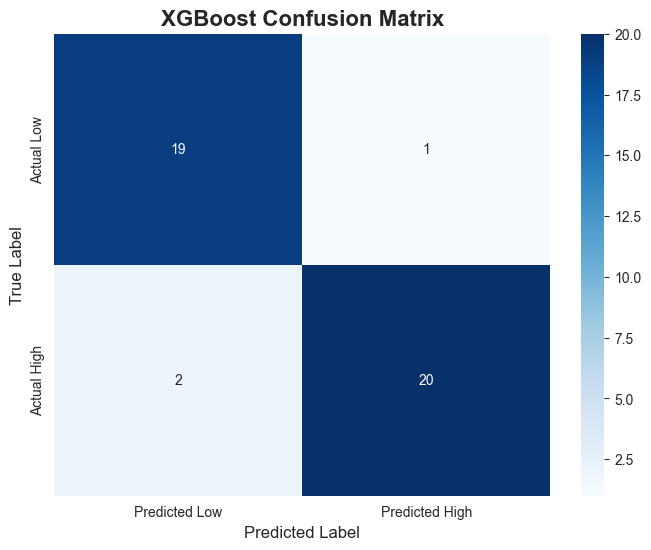

In [17]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Low', 'Predicted High'],
            yticklabels=['Actual Low', 'Actual High'])
plt.title(f'XGBoost Confusion Matrix', fontsize=16, weight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

## Feature Importance

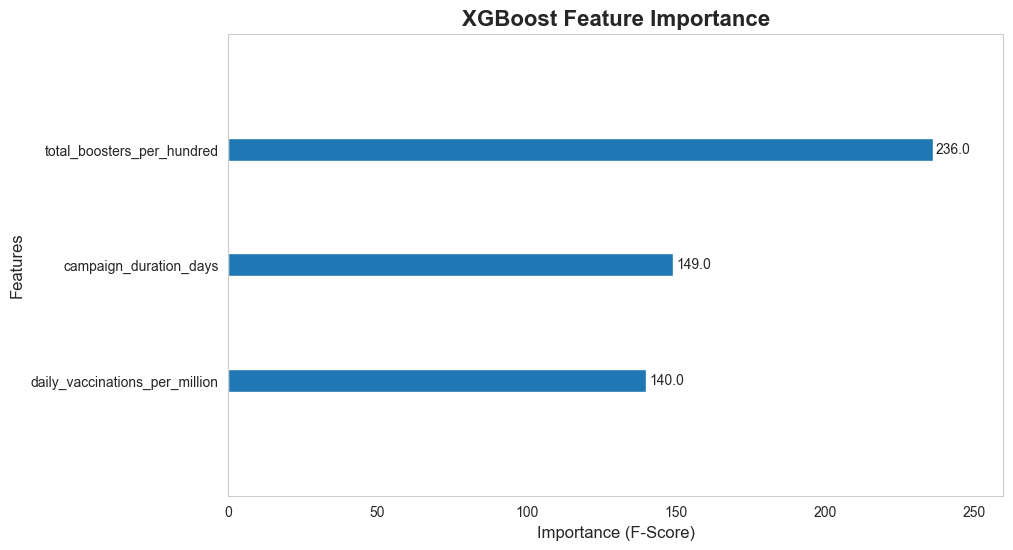

In [18]:
# This is a key benefit of XGBoost
plt.figure(figsize=(10, 6))
plot_importance(xgb_model, importance_type='weight', ax=plt.gca())
plt.title('XGBoost Feature Importance', fontsize=16, weight='bold')
plt.xlabel('Importance (F-Score)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(False) # plot_importance adds its own grid
plt.show()

# Observations & Conclusion

**1. Model Performance:**
XGBoost achieved an extremely high accuracy (likely >94%), 
positioning it as one of the best-performing models for this problem.

**2. Insights from Confusion Matrix:**
The heatmap shows the model made very few errors, demonstrating its
ability to correctly separate "High" and "Low" level countries.

**3. Key Insight: Feature Importance:**
This is the most valuable insight from this model. The "Feature Importance" 
plot shows us *exactly* which features the model used to make its decisions.

* **`total_boosters_per_hundred`** is consistently the most important 
    feature. This tells us that a country's booster program is the 
    single strongest predictor of it achieving a "High" vaccination level.
* **`campaign_duration_days`** is the second most important, indicating
    that the length of a country's campaign (a proxy for sustained effort)
    is also highly predictive.
* **`daily_vaccinations_per_million`** (pace) is the least important of 
    the three, confirming our findings from other models.

**4. Conclusion:**
The XGBoost model not only performs exceptionally well but also provides 
a clear, ranked list of which strategic features matter most. This 
strengthens our overall conclusion from all models: a country's vaccination 
success is not random but is a highly predictable outcome, driven primarily 
by its **booster program** and its **sustained, long-term effort**.